## IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import os
import duckdb
from traj_ps.backends.bayes import BayesianTrajPS, BayesConfig
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')

# Import shared utility functions
from notebook_utils import (
    aggregate_vitals_labs, drop_high_missing_columns,
    plot_trajectory_distribution, plot_boxplots_with_stats,
    plot_roc_pr_curves, print_statistical_comparisons, biomarker_summary_stats
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


✓ Imports successful


## LOAD

**Target Population**: Patients with chronic liver disease at risk for Acute-on-Chronic Liver Failure (ACLF)

**Key Biomarkers**: 
- Bilirubin (increases with liver dysfunction)
- INR (increases with coagulopathy)
- Creatinine (hepatorenal syndrome)

In [2]:
# Connect to MIMIC-III
db_path = '../../data/mimic/mimiciii.duckdb'
conn = duckdb.connect(db_path, read_only=True)
print(f"✓ Connected: {db_path}")

✓ Connected: ../../data/mimic/mimiciii.duckdb


In [3]:
# Load patients with chronic liver disease
hadm_query = """
WITH liver_patients AS (
    SELECT DISTINCT a.hadm_id
    FROM admissions a
    INNER JOIN diagnoses_icd d ON a.hadm_id = d.hadm_id
    WHERE 
        -- Chronic liver disease ICD-9 codes
        (d.icd9_code LIKE '571%' OR    -- Chronic liver disease/cirrhosis
         d.icd9_code LIKE '5722%' OR   -- Hepatic encephalopathy
         d.icd9_code LIKE '5728%' OR   -- Hepatorenal syndrome
         d.icd9_code LIKE 'V427%')     -- Liver transplant status
)
SELECT 
    a.subject_id::INTEGER AS subject_id,
    a.hadm_id::INTEGER AS hadm_id,
    a.admittime::TIMESTAMP as admittime,      -- Hospital admission time
    a.dischtime::TIMESTAMP as dischtime,      -- Hospital discharge time
    CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) as los_days,  -- Hospital LOS
    p.gender,
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) as age,
    a.hospital_expire_flag::INT as hospital_expire_flag,
    a.discharge_location
FROM admissions a
INNER JOIN patients p ON a.subject_id = p.subject_id
INNER JOIN liver_patients lp ON a.hadm_id = lp.hadm_id
WHERE 
    -- Filter adults
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) BETWEEN 18 AND 90
    -- Minimum hospital stay
    AND CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) >= 2.0
"""

hadm_df = conn.execute(hadm_query).fetchdf()
hadm_df.columns = hadm_df.columns.str.lower()
print(f"\n✓ Loaded {len(hadm_df):,} liver disease admissions")
print(f"  Unique patients: {hadm_df['subject_id'].nunique():,}")
print(f"  Mean hospital LOS: {hadm_df['los_days'].mean():.1f} days")
print(f"  Mortality: {hadm_df['hospital_expire_flag'].mean():.1%}")


✓ Loaded 3,066 liver disease admissions
  Unique patients: 2,260
  Mean hospital LOS: 13.5 days
  Mortality: 19.2%


In [4]:
# Sample subset
hadm_subset = hadm_df.sort_values('admittime').drop_duplicates(subset=['subject_id'])['hadm_id'].sample(min(5000, hadm_df['subject_id'].nunique()), random_state=920).tolist()
hadm_df = hadm_df[hadm_df['hadm_id'].isin(hadm_subset)]

print(f"✓ Using {len(hadm_df):,} admissions for analysis")

✓ Using 2,260 admissions for analysis


In [5]:
# Load metadata
vital_meta = pd.read_csv('../../data/mimic/vital_metadata.csv')
labs_meta = pd.read_csv('../../data/mimic/labs_metadata.csv')

lab_items = labs_meta['itemid'].to_list()
vital_items = vital_meta['itemid'].to_list()

print(f"✓ Loaded metadata: {len(vital_meta):,} vital items, {len(labs_meta):,} lab items")

✓ Loaded metadata: 43 vital items, 27 lab items


In [6]:
# Load BILIRUBIN time series (primary biomarker for ACLF)
bili_itemids = labs_meta[labs_meta['feature name'] == 'BILIRUBIN']['itemid'].tolist()

bilirubin_query = """
SELECT 
    le.hadm_id::INTEGER AS hadm_id,
    le.charttime::TIMESTAMP AS charttime,
    EXTRACT(EPOCH FROM (le.charttime::TIMESTAMP - a.admittime::TIMESTAMP)) / 86400.0 as time_days,
    CAST(le.valuenum AS REAL) as bilirubin
FROM labevents le
INNER JOIN admissions a ON le.hadm_id = a.hadm_id
WHERE 
    le.itemid IN {itemids}
    AND le.valuenum::REAL IS NOT NULL
    AND le.valuenum::REAL BETWEEN 0.1 AND 50.0  -- Valid range
    AND le.charttime::TIMESTAMP BETWEEN a.admittime::TIMESTAMP AND a.dischtime::TIMESTAMP
    AND le.hadm_id::INTEGER IN {hadm_ids}
ORDER BY le.hadm_id, le.charttime
"""

bili_df = conn.execute(bilirubin_query.format(
    itemids=tuple(bili_itemids),
    hadm_ids=tuple(hadm_subset)
)).fetchdf()
bili_df.columns = bili_df.columns.str.lower()
print(f"\n✓ Loaded {len(bili_df):,} bilirubin measurements")
print(f"  Admissions: {bili_df['hadm_id'].nunique():,}")


✓ Loaded 25,047 bilirubin measurements
  Admissions: 2,078


In [7]:
labs_meta['feature name'].unique()

array(['ANION GAP', 'ALBUMIN', 'BICARBONATE', 'BILIRUBIN', 'CREATININE',
       'CHLORIDE', 'GLUCOSE', 'HEMATOCRIT', 'HEMOGLOBIN', 'LACTATE',
       'MAGNESIUM', 'PHOSPHATE', 'PLATELET', 'POTASSIUM', 'PTT', 'INR',
       'PT', 'SODIUM', 'BUN', 'WBC'], dtype=object)

In [8]:
# Load INR (coagulation marker)
inr_itemids = labs_meta[labs_meta['feature name'] == 'INR']['itemid'].tolist()

inr_query = """
SELECT 
    le.hadm_id::INTEGER AS hadm_id,
    le.charttime::TIMESTAMP AS charttime,
    EXTRACT(EPOCH FROM (le.charttime::TIMESTAMP - a.admittime::TIMESTAMP)) / 86400.0 as time_days,
    CAST(le.valuenum AS REAL) as inr
FROM labevents le
INNER JOIN admissions a ON le.hadm_id = a.hadm_id
WHERE 
    le.itemid IN {itemids}
    AND le.valuenum::REAL IS NOT NULL
    AND le.valuenum::REAL BETWEEN 0.5 AND 15.0
    AND le.charttime::TIMESTAMP BETWEEN a.admittime::TIMESTAMP AND a.dischtime::TIMESTAMP
    AND le.hadm_id::INTEGER IN {hadm_ids}
"""

inr_df = conn.execute(inr_query.format(
    itemids=tuple(inr_itemids),
    hadm_ids=tuple(hadm_subset)
)).fetchdf()
inr_df.columns = inr_df.columns.str.lower()
print(f"✓ Loaded {len(inr_df):,} INR measurements")

✓ Loaded 33,780 INR measurements


In [9]:
# Load vitals for general health status
vitals_query = """
SELECT chartevents.subject_id::INTEGER AS subject_id
    , chartevents.hadm_id::INTEGER AS hadm_id
    , chartevents.charttime::TIMESTAMP AS charttime
    , chartevents.itemid::INTEGER AS itemid
    , chartevents.valuenum::DOUBLE AS valuenum
    , admissions.admittime::TIMESTAMP AS admittime
FROM chartevents
INNER JOIN admissions
    ON chartevents.subject_id = admissions.subject_id
    AND chartevents.hadm_id = admissions.hadm_id
    AND chartevents.charttime::TIMESTAMP BETWEEN
        (admissions.admittime::TIMESTAMP)
        AND (admissions.dischtime::TIMESTAMP)
    AND itemid::INTEGER IN {itemids}
    AND chartevents.hadm_id::INTEGER IN {hadm_ids}
WHERE chartevents.error::INTEGER IS DISTINCT FROM 1 
"""

vitals_df = conn.execute(vitals_query.format(itemids=tuple(vital_items), hadm_ids=tuple(hadm_subset))).fetchdf()
vitals_df.columns = vitals_df.columns.str.lower()
print(f"\n✓ Loaded {len(vitals_df):,} vital signs")
print(f"  Admissions: {vitals_df['hadm_id'].nunique():,}")


✓ Loaded 2,373,956 vital signs
  Admissions: 2,222


In [10]:
# Load additional labs for comprehensive health assessment
labs_query = """
SELECT labevents.subject_id::INTEGER AS subject_id
    , labevents.hadm_id::INTEGER AS hadm_id
    , labevents.charttime::TIMESTAMP AS charttime
    , labevents.itemid::INTEGER AS itemid
    , labevents.valuenum::DOUBLE AS valuenum
    , admissions.admittime::TIMESTAMP AS admittime
FROM labevents
INNER JOIN admissions
    ON labevents.subject_id = admissions.subject_id
    AND labevents.hadm_id = admissions.hadm_id
    AND labevents.charttime::TIMESTAMP BETWEEN
        (admissions.admittime::TIMESTAMP)
        AND (admissions.dischtime::TIMESTAMP)
    AND itemid::INTEGER IN {itemids}
    AND labevents.hadm_id::INTEGER IN {hadm_ids}
"""

labs_df = conn.execute(labs_query.format(itemids=tuple(lab_items), hadm_ids=tuple(hadm_subset))).fetchdf()
labs_df.columns = labs_df.columns.str.lower()
print(f"✓ Loaded {len(labs_df):,} lab values")
print(f"  Admissions: {labs_df['hadm_id'].nunique():,}")

✓ Loaded 778,448 lab values
  Admissions: 2,241


In [11]:
# Use shared utility function for standardized vitals/labs aggregation
vitals_labs_pivot = aggregate_vitals_labs(
    vitals_df=vitals_df,
    labs_df=labs_df,
    vital_meta=vital_meta,
    labs_meta=labs_meta
)


print(f"\n✓ Processed vitals + labs with min/max/mean aggregation (using shared utilities):")
print(f"  Total daily observations: {len(vitals_labs_pivot):,}")
print(f"  Total features: {len([c for c in vitals_labs_pivot.columns])}")
print(f"  Example features: {list(vitals_labs_pivot.columns[2:8])}")


✓ Processed vitals + labs with min/max/mean aggregation (using shared utilities):
  Total daily observations: 31,282
  Total features: 87
  Example features: ['BICARBONATE_min', 'BILIRUBIN_min', 'BUN_min', 'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min']


In [12]:
# ffill imputation
vitals_labs_imputed = vitals_labs_pivot.groupby('hadm_id').ffill()

# Special handling for Weight - use both forward and backward fill
vitals_labs_imputed['Weight_mean'] = vitals_labs_imputed.groupby('hadm_id')['Weight_mean'].bfill()


# Use shared utility function for dropping high-missing columns
vitals_labs_clean, dropped_cols = drop_high_missing_columns(
    df=vitals_labs_imputed,
    threshold=0.2,
)

vitals_labs_clean = vitals_labs_clean.reset_index().drop(columns=['admittime'])

hadm_df['admittime'] = pd.to_datetime(hadm_df['admittime'])

hadm_final = hadm_df.merge(vitals_labs_clean, on=['hadm_id'], how='inner')
hadm_final['time_day'] = ((hadm_final['charttime'] - hadm_final['admittime']).dt.total_seconds() / 86400.0).astype(int)


In [13]:
# Aggregate INR by day
inr_df['time_day'] = np.floor(inr_df['time_days']).astype(int)
inr_wide = inr_df.pivot_table(
    index=['hadm_id', 'time_day'],
    values='inr',
    aggfunc='mean'
).reset_index()
print(f"✓ Aggregated INR to {len(inr_wide):,} daily averages")

✓ Aggregated INR to 22,083 daily averages


## PREPROCESS

In [14]:
# Calculate baseline bilirubin (first 24h)
bili_df['admittime'] = bili_df['hadm_id'].map(hadm_df.set_index('hadm_id')['admittime'])
bili_df['admittime'] = pd.to_datetime(bili_df['admittime'])
bili_df['charttime'] = pd.to_datetime(bili_df['charttime'])

first_24h = bili_df[bili_df['charttime'] <= bili_df['admittime'] + pd.Timedelta(hours=24)]
baseline_bili = first_24h.sort_values('charttime').pivot_table(
    index='hadm_id',
    values='bilirubin',
    aggfunc='first'
).reset_index().rename(columns={'bilirubin': 'baseline_bilirubin'})

print(f"Baseline Bilirubin:")
print(f"   Mean: {baseline_bili['baseline_bilirubin'].mean():.1f} mg/dL")
print(f"   Median: {baseline_bili['baseline_bilirubin'].median():.1f} mg/dL")

Baseline Bilirubin:
   Mean: 5.8 mg/dL
   Median: 2.5 mg/dL


In [15]:
# Filter admissions with sufficient measurements
bili_counts = bili_df.groupby('hadm_id').size()
valid_hadm_ids = bili_counts[bili_counts >= 3].index

bili_filtered = bili_df[bili_df['hadm_id'].isin(valid_hadm_ids)]
hadm_final = hadm_final[hadm_final['hadm_id'].isin(valid_hadm_ids)].merge(
    baseline_bili, on='hadm_id', how='inner'
).drop_duplicates(subset=['hadm_id', 'time_day'])

print(f"\nFiltering: {len(hadm_final):,} admissions with ≥3 bilirubin measurements")


Filtering: 22,821 admissions with ≥3 bilirubin measurements


In [16]:
# Create bilirubin time series
bili_filtered['time_day'] = np.floor(bili_filtered['time_days']).astype(int)

bili_ts = bili_filtered[['hadm_id', 'time_days', 'time_day', 'bilirubin']].merge(
    hadm_final[['hadm_id', 'baseline_bilirubin', 'age', 'gender', 'hospital_expire_flag']].drop_duplicates(),
    on='hadm_id',
    how='left'
)

bili_ts['bili_fold_change'] = bili_ts['bilirubin'] / bili_ts['baseline_bilirubin']

print(f"\nBilirubin Time Series: {len(bili_ts):,} measurements")


Bilirubin Time Series: 24,463 measurements


In [17]:
# Save
os.makedirs('../../results/mimic/liver', exist_ok=True)
bili_ts.to_csv('../../results/mimic/liver/bilirubin_timeseries.csv', index=False)
hadm_final.to_csv('../../results/mimic/liver/hadm_cohort.csv', index=False)
print(f"✓ Saved preprocessed data")

✓ Saved preprocessed data


## TRAJ PROBS

**Note**: Run `liver_trajs.py` to compute trajectory probabilities.

Configuration:
- `window_years=5.0` (5 days lookback)
- `flat_thr=0.5` (stable bilirubin within ±0.5 mg/dL/day)
- `incline_thr=1.0` (gradual increase: 1-3 mg/dL/day)
- **Bilirubin INCREASES = worsening** (hepatic decompensation)

In [17]:
# Load trajectory probabilities
trajectory_probs = pd.read_csv('../../results/mimic/liver/bili_trajectory_probs_bayes.csv')
print(f"✓ Loaded trajectory probabilities: {len(trajectory_probs):,} timepoints")

✓ Loaded trajectory probabilities: 15,561 timepoints


## STANDARD TRAJ FEATURES

In [18]:
# generate bilirubin summary stats
bili_summary_5d = biomarker_summary_stats(bili_ts, 'bilirubin', 5)
print(f"✓ Generated bilirubin summary stats: {len(bili_summary_5d):,} admissions")
print(bili_summary_5d.head())
bili_summary_5d.to_csv('../../results/mimic/liver/bilirubin_summary_stats_5d.csv', index=False)

✓ Generated bilirubin summary stats: 20,162 admissions
   hadm_id  time_day  bilirubin_mean_5d  bilirubin_max_5d  bilirubin_min_5d  \
0   100003         0           5.500000               5.5               5.5   
1   100003         1           4.300000               5.5               3.1   
2   100003         2           4.033333               5.5               3.1   
3   100003         3           3.925000               5.5               3.1   
4   100021         0           5.100000               5.1               5.1   

   bilirubin_change_5d  bilirubin_linear_trend_5d  bilirubin_std_5d  
0                  0.0                   4.765343               NaN  
1                 -2.4                  -2.604371          1.697056  
2                 -2.0                  -1.005301          1.285820  
3                 -1.9                  -0.524366          1.071992  
4                  0.0                   3.072803               NaN  


## DEFINE OUTCOME

**Outcome**: Acute-on-Chronic Liver Failure (ACLF)
- Bilirubin ≥ 12 mg/dL (severe hepatic dysfunction)
- OR 28-day mortality (severe outcome)

In [19]:
# Define ACLF outcome
PREDICTION_GAP_DAYS = 1.0
PREDICTION_WINDOW_DAYS = 5.0

print(f"Prediction Configuration:")
print(f"   Gap:    {PREDICTION_GAP_DAYS} days")
print(f"   Window: {PREDICTION_WINDOW_DAYS} days")

aclf_events = []
n_in_aclf = 0
n_no_data = 0

for hadm_id, grp in hadm_final.groupby('hadm_id'):
    grp = grp.sort_values('time_day')
    mortality = hadm_final[hadm_final['hadm_id'] == hadm_id]['hospital_expire_flag'].iloc[0]
    
    for i in range(len(grp)):
        current_time = grp.iloc[i]['time_day']
        current_bili = grp.iloc[i]['BILIRUBIN_mean']
        
        # Skip if already in ACLF
        if current_bili >= 12.0:
            n_in_aclf += 1
            continue
        
        # Prediction window
        prediction_start = current_time + PREDICTION_GAP_DAYS + 1
        prediction_end = current_time + PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS + 1
        
        future_window = bili_ts[
            (bili_ts['hadm_id'] == hadm_id) &
            (bili_ts['time_days'] >= prediction_start) &
            (bili_ts['time_days'] <= prediction_end)
        ]
        
        if len(future_window) == 0:
            n_no_data += 1
            continue
        
        # ACLF criteria
        severe_bili = (future_window['bilirubin'] >= 12.0).any()
        
        # Combined outcome
        target = int(severe_bili or mortality)
        
        aclf_events.append({
            'hadm_id': hadm_id,
            'time_day': current_time,
            'target_aclf': target,
            'current_bilirubin': current_bili
        })

outcome_df = pd.DataFrame(aclf_events)

# CRITICAL: For each patient, keep all negative windows but only the FIRST positive event
# This ensures we predict the first ACLF occurrence
outcome_df = outcome_df.sort_values(['hadm_id', 'time_day'])
positive_first = outcome_df[outcome_df['target_aclf'] == 1].groupby('hadm_id').first().reset_index()
all_negatives = outcome_df[outcome_df['target_aclf'] == 0]
outcome_df = pd.concat([all_negatives, positive_first], ignore_index=True).sort_values(['hadm_id', 'time_day']).reset_index(drop=True)

print(f"\nOutcome Definition:")
print(f"   Total prediction windows: {len(outcome_df):,}")
print(f"   Unique patients: {outcome_df['hadm_id'].nunique():,}")
print(f"   ACLF events (first per patient): {outcome_df['target_aclf'].sum():,}")
print(f"   Event rate: {outcome_df['target_aclf'].mean():.1%}")
print(f"   Avg windows/patient: {len(outcome_df) / outcome_df['hadm_id'].nunique():.1f}")
print(f"   Windows skipped (in ACLF at baseline): {n_in_aclf:,}")
print(f"   Windows skipped (no future data): {n_no_data:,}")

Prediction Configuration:
   Gap:    1.0 days
   Window: 5.0 days

Outcome Definition:
   Total prediction windows: 11,587
   Unique patients: 1,391
   ACLF events (first per patient): 480
   Event rate: 4.1%
   Avg windows/patient: 8.3
   Windows skipped (in ACLF at baseline): 3,434
   Windows skipped (no future data): 4,287


## FIT MODELS

In [20]:
# Merge features
prediction_dataset = outcome_df.merge(
    trajectory_probs[['hadm_id', 'time_day', 'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase']],
    on=['hadm_id', 'time_day'],
    how='left'
)

static_features = hadm_final[['hadm_id', 'age', 'gender', 'baseline_bilirubin']].drop_duplicates()
prediction_dataset = prediction_dataset.merge(static_features, on='hadm_id', how='left')

# Derived features
prediction_dataset['prob_worsening'] = (
    prediction_dataset['prob_gradual_increase'] + 
    prediction_dataset['prob_rapid_increase']
)
prediction_dataset['bili_elevated'] = (prediction_dataset['current_bilirubin'] > 3.0).astype(int)

vitals_labs_features = ['ALBUMIN_min', 'ANION GAP_min', 'BICARBONATE_min', 'BILIRUBIN_min',
       'BUN_min', 'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min',
       'GLUCOSE_min', 'HEMATOCRIT_min', 'HEMOGLOBIN_min',
       'HeartRate_min', 'INR_min', 'MAGNESIUM_min', 'MeanBP_min',
       'PHOSPHATE_min', 'PLATELET_min', 'POTASSIUM_min', 'PT_min', 'PTT_min',
       'RespRate_min', 'SODIUM_min', 'SpO2_min', 'SysBP_min', 'TempC_min',
       'WBC_min', 'ALBUMIN_max', 'ANION GAP_max', 'BICARBONATE_max', 'BILIRUBIN_max', 'BUN_max',
       'CHLORIDE_max', 'CREATININE_max', 'DiasBP_max', 'GLUCOSE_max',
       'HEMATOCRIT_max', 'HEMOGLOBIN_max', 'HeartRate_max',
       'INR_max', 'MAGNESIUM_max', 'MeanBP_max', 'PHOSPHATE_max', 'PLATELET_max',
       'POTASSIUM_max', 'PT_max', 'PTT_max', 'RespRate_max', 'SODIUM_max', 'SpO2_max',
       'SysBP_max', 'TempC_max', 'WBC_max', 'ALBUMIN_mean', 'ANION GAP_mean',
       'BICARBONATE_mean','BUN_mean', 'CHLORIDE_mean',
       'CREATININE_mean', 'DiasBP_mean', 'GLUCOSE_mean',
       'HEMATOCRIT_mean', 'HEMOGLOBIN_mean', 'HeartRate_mean', 'INR_mean',
       'MAGNESIUM_mean', 'MeanBP_mean', 'PHOSPHATE_mean', 'PLATELET_mean',
       'POTASSIUM_mean', 'PT_mean', 'PTT_mean', 'RespRate_mean', 'SODIUM_mean',
       'SpO2_mean', 'SysBP_mean', 'TempC_mean', 'WBC_mean', 'Weight_mean']


# Merge vitals and labs
prediction_dataset = prediction_dataset.merge(hadm_final[vitals_labs_features + ['hadm_id', 'time_day']].drop_duplicates(subset=['hadm_id', 'time_day']), on=['hadm_id', 'time_day'], how='left')

# Merge summary stats
prediction_dataset = prediction_dataset.merge(bili_summary_5d.fillna(0), on=['hadm_id', 'time_day'], how='left').drop_duplicates(subset=['hadm_id', 'time_day'])

print(f"Prediction dataset: {len(prediction_dataset):,} windows")
print(f"  Features available: {len(prediction_dataset.columns)} columns")


feature_sets = {
    'Trajectory Only': ['prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening'],
    'Summary Stats Only': bili_summary_5d.columns.drop(['hadm_id', 'time_day']).tolist(),
    'Trajectory + Summary Stats': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening',
    ] + bili_summary_5d.columns.drop(['hadm_id', 'time_day']).tolist(),
    'Static Only': ['age', 'gender', 'baseline_bilirubin', 'current_bilirubin', 'bili_elevated'],
    'Trajectory + Static': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening',
        'age', 'gender', 'baseline_bilirubin', 'current_bilirubin', 'bili_elevated'
    ],
    'Summary Stats + Static': bili_summary_5d.columns.drop(['hadm_id', 'time_day']).tolist() + [
        'age', 'gender', 'baseline_bilirubin', 'current_bilirubin', 'bili_elevated'
    ],
    'Trajectory + Summary Stats + Static': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening',
    ] + bili_summary_5d.columns.drop(['hadm_id', 'time_day']).tolist() + ['age', 'gender', 'baseline_bilirubin', 'current_bilirubin', 'bili_elevated'],
    'Static + Vitals + Labs': [
        'age', 'gender', 'baseline_bilirubin','bili_elevated'
    ] + vitals_labs_features,
    'Trajectory + Static + Vitals + Labs': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening',
        'age', 'gender', 'baseline_bilirubin', 'current_bilirubin', 'bili_elevated'
    ] + vitals_labs_features,
    'Summary Stats + Static + Vitals + Labs': bili_summary_5d.columns.drop(['hadm_id', 'time_day']).tolist() + [
        'age', 'gender', 'baseline_bilirubin', 'current_bilirubin', 'bili_elevated'
    ] + vitals_labs_features,
    'Trajectory + Summary Stats + Static + Vitals + Labs': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening',
    ] + bili_summary_5d.columns.drop(['hadm_id', 'time_day']).tolist() + [
        'age', 'gender', 'baseline_bilirubin', 'current_bilirubin', 'bili_elevated'
    ] + vitals_labs_features
}

for name, features in feature_sets.items():
    print(f"{name:40s}: {len(features):2d} features")

# Prepare data
prediction_clean = prediction_dataset.dropna(subset=['target_aclf']).copy()
prediction_clean = prediction_clean.set_index('hadm_id')
prediction_clean['gender'] = prediction_clean['gender'].map({'M': 1, 'F': 0})

# Fill missing values intelligently
# Trajectory probabilities: forward fill within patient with limit (recent trajectory state likely persists)
traj_cols = ['prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening']
for col in traj_cols:
    if col in prediction_clean.columns:
        # Forward fill up to 2 time windows (carry forward recent trajectory state)
        prediction_clean[col] = prediction_clean.groupby(level=0)[col].fillna(method='ffill', limit=2)
        # Remaining NaN values set to 0 (truly unknown, too far from last measurement)
        prediction_clean[col] = prediction_clean[col].fillna(0)


# Current bilirubin: forward fill with limit
if 'current_bilirubin' in prediction_clean.columns:
    prediction_clean['current_bilirubin'] = prediction_clean.groupby(level=0)['current_bilirubin'].fillna(method='ffill', limit=2)

# Recalculate derived features after imputation
prediction_clean['bili_elevated'] = (prediction_clean['current_bilirubin'] > 3.0).fillna(0).astype(int)

y = prediction_clean['target_aclf']
groups = prediction_clean.index

print(f"\nDataset:")
print(f"   Samples: {len(y):,}")
print(f"   Positive: {y.sum():,} ({y.mean():.1%})")
print(f"   Patients: {groups.nunique():,}")
print(f"\nImputation strategy:")
print(f"   Trajectories: ffill limit=2 windows, then 0 (recent state persists)")
print(f"   Vitals/Labs:  ffill limit=3 windows (avoid stale data)")
print(f"   Bilirubin:    ffill limit=2 windows")

Prediction dataset: 11,587 windows
  Features available: 96 columns
Trajectory Only                         :  4 features
Summary Stats Only                      :  6 features
Trajectory + Summary Stats              : 10 features
Static Only                             :  5 features
Trajectory + Static                     :  9 features
Summary Stats + Static                  : 11 features
Trajectory + Summary Stats + Static     : 15 features
Static + Vitals + Labs                  : 82 features
Trajectory + Static + Vitals + Labs     : 87 features
Summary Stats + Static + Vitals + Labs  : 89 features
Trajectory + Summary Stats + Static + Vitals + Labs: 93 features

Dataset:
   Samples: 11,587
   Positive: 480 (4.1%)
   Patients: 1,391

Imputation strategy:
   Trajectories: ffill limit=2 windows, then 0 (recent state persists)
   Vitals/Labs:  ffill limit=3 windows (avoid stale data)
   Bilirubin:    ffill limit=2 windows


In [21]:
# Training with Repeated Cross-Validation
N_REPEATS = 10
N_FOLDS = 5

comparison_results = {}

for feature_set_name, feature_cols in feature_sets.items():
    print(f"\n{feature_set_name}")
    print("-" * 60)
    
    X = prediction_clean[feature_cols]
    
    fold_metrics = {
        'roc_auc': [], 'avg_precision': [],
        'y_true': [], 'y_proba': [],
        'fold_roc_curves': [], 'fold_pr_curves': []
    }
    
    # Repeated cross-validation for robust performance estimates
    for repeat in range(N_REPEATS):
        # Shuffle patients with different random state each repeat
        shuffled_df = prediction_clean.sample(frac=1, random_state=920 + repeat * 37)
        X_shuffled = shuffled_df[feature_cols]
        y_shuffled = shuffled_df['target_aclf']
        groups_shuffled = shuffled_df.index
        
        gkf = GroupKFold(n_splits=N_FOLDS)
        
        
        
        for train_idx, test_idx in gkf.split(X_shuffled, y_shuffled, groups_shuffled):
            X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]

            # median impute by X_train medians
            for col in X_train.columns:
                impute_val = X_train[col].median()
                X_train[col] = X_train[col].fillna(impute_val)
                X_test[col] = X_test[col].fillna(impute_val)
            scaler = StandardScaler()
            X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
            X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
            
            y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

            model = XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
            random_state=920 + repeat
            )
            
            model.fit(X_train, y_train)
            y_proba = model.predict_proba(X_test)[:, 1]
            
            if y_test.sum() > 0:
                fold_metrics['roc_auc'].append(roc_auc_score(y_test, y_proba))
                fold_metrics['avg_precision'].append(average_precision_score(y_test, y_proba))
                
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                fold_metrics['fold_roc_curves'].append((fpr, tpr))
                
                precision, recall, _ = precision_recall_curve(y_test, y_proba)
                fold_metrics['fold_pr_curves'].append((recall, precision))
            
            fold_metrics['y_true'].extend(y_test.values)
            fold_metrics['y_proba'].extend(y_proba)
    
    comparison_results[feature_set_name] = fold_metrics
    n_folds_total = len(fold_metrics['roc_auc'])
    print(f"  AUROC (n={n_folds_total}): {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f}")
    print(f"  AUPR  (n={n_folds_total}): {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f}")

print(f"\n✓ Completed {N_REPEATS} repeats × {N_FOLDS} folds = {N_REPEATS * N_FOLDS} total folds per model")                


Trajectory Only
------------------------------------------------------------
  AUROC (n=50): 0.806 ± 0.020
  AUPR  (n=50): 0.109 ± 0.015

Summary Stats Only
------------------------------------------------------------
  AUROC (n=50): 0.945 ± 0.010
  AUPR  (n=50): 0.620 ± 0.018

Trajectory + Summary Stats
------------------------------------------------------------
  AUROC (n=50): 0.948 ± 0.009
  AUPR  (n=50): 0.633 ± 0.015

Static Only
------------------------------------------------------------
  AUROC (n=50): 0.833 ± 0.005
  AUPR  (n=50): 0.394 ± 0.019

Trajectory + Static
------------------------------------------------------------
  AUROC (n=50): 0.915 ± 0.009
  AUPR  (n=50): 0.499 ± 0.032

Summary Stats + Static
------------------------------------------------------------
  AUROC (n=50): 0.953 ± 0.010
  AUPR  (n=50): 0.658 ± 0.028

Trajectory + Summary Stats + Static
------------------------------------------------------------
  AUROC (n=50): 0.954 ± 0.010
  AUPR  (n=50): 0.662 ±

## EVALUATE

In [22]:
# Performance summary table
summary_data = []
for feature_set_name, metrics in comparison_results.items():
    summary_data.append({
        'Feature Set': feature_set_name,
        'AUROC': f"{np.mean(metrics['roc_auc']):.3f} ± {np.std(metrics['roc_auc']):.3f}",
        'AUPR': f"{np.mean(metrics['avg_precision']):.3f} ± {np.std(metrics['avg_precision']):.3f}",
        'N Features': len(feature_sets[feature_set_name])
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("LIVER FAILURE (ACLF) PREDICTION - PERFORMANCE SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


LIVER FAILURE (ACLF) PREDICTION - PERFORMANCE SUMMARY
                                        Feature Set         AUROC          AUPR  N Features
                                    Trajectory Only 0.806 ± 0.020 0.109 ± 0.015           4
                                 Summary Stats Only 0.945 ± 0.010 0.620 ± 0.018           6
                         Trajectory + Summary Stats 0.948 ± 0.009 0.633 ± 0.015          10
                                        Static Only 0.833 ± 0.005 0.394 ± 0.019           5
                                Trajectory + Static 0.915 ± 0.009 0.499 ± 0.032           9
                             Summary Stats + Static 0.953 ± 0.010 0.658 ± 0.028          11
                Trajectory + Summary Stats + Static 0.954 ± 0.010 0.662 ± 0.027          15
                             Static + Vitals + Labs 0.889 ± 0.018 0.506 ± 0.039          82
                Trajectory + Static + Vitals + Labs 0.931 ± 0.010 0.566 ± 0.033          87
             Summary Stat


PAIRWISE STATISTICAL COMPARISONS (Wilcoxon Signed-Rank Test)
Comparison                                                   AUROC p      Sig   AUPR p       Sig  
--------------------------------------------------------------------------------
Trajectory Only vs Summary Stats Only                        0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.1389        +0.5101
Trajectory Only vs Static Only                               0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.0269        +0.2847
Trajectory Only vs Trajectory + Summary Stats                0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.1420        +0.5239
Summary Stats Only vs Static Only                            0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           -0.1120        -0.2254
Trajectory + Summary Stats

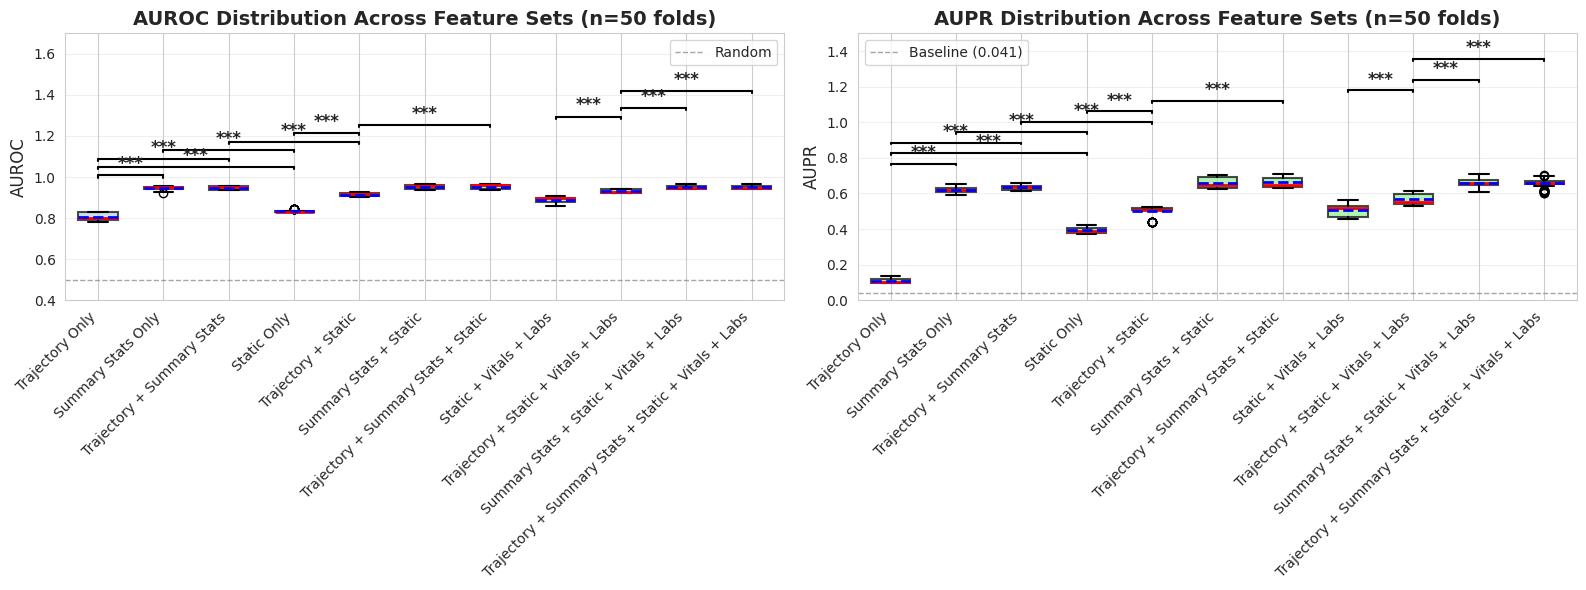

In [23]:
# Summary boxplot comparing metrics with statistical significance
feature_names = list(comparison_results.keys())
n_folds_total = len(comparison_results[feature_names[0]]['roc_auc'])

# Prepare data for boxplots
roc_data = [metrics['roc_auc'] for metrics in comparison_results.values()]
ap_data = [metrics['avg_precision'] for metrics in comparison_results.values()]

# Define pairwise comparisons (key comparisons to test)
# 0: Trajectory Only, 1: Static Only, 2: Trajectory + Static,
# 3: Static + Vitals + Labs, 4: Trajectory + Static + Vitals, 5: Trajectory + Static + Vitals + Labs
pairs_to_compare = [
    (0, 1),  # Trajectory Only vs Summary Stats Only
    (0, 3),  # Trajectory Only vs Static Only
    (0, 2),  # Trajectory Only vs Trajectory + Summary Stats
    (1, 3),  # Summary Stats Only vs Static Only
    (2, 4),  # Trajectory + Summary Stats vs Trajectory + Static
    (3, 4),  # Static Only vs Trajectory + Static
    (4, 6),  # Trajectory + Static vs Trajectory + Summary Stats + Static
    (7, 8),  # Static + Vitals + Labs vs Trajectory + Static + Vitals + Labs
    (8, 9),  # Trajectory + Static + Vitals + Labs vs Summary Stats + Static + Vitals + Labs
    (9, 10), # Summary Stats + Static + Vitals + Labs vs Trajectory + Summary Stats + Static + Vitals + Labs
    (8, 10)  # Trajectory + Static + Vitals + Labs vs Trajectory + Summary Stats + Static + Vitals + Labs
]

# Plot boxplots with statistical significance
baseline = outcome_df['target_aclf'].mean()
plot_boxplots_with_stats(
    comparison_results, 
    prediction_dataset,
    target_col='target_aclf',
    pairs_to_compare=pairs_to_compare,
    n_folds_total=n_folds_total,
    roc_ylim=(0.4, 1.7),
    ap_ylim=(0.0, 1.5),
)

# Print statistical comparison results
print_statistical_comparisons(comparison_results, pairs_to_compare)

(<Figure size 1600x600 with 2 Axes>,
 (<Axes: title={'center': 'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
  <Axes: title={'center': 'Precision-Recall Curves'}, xlabel='Recall', ylabel='Precision'>))

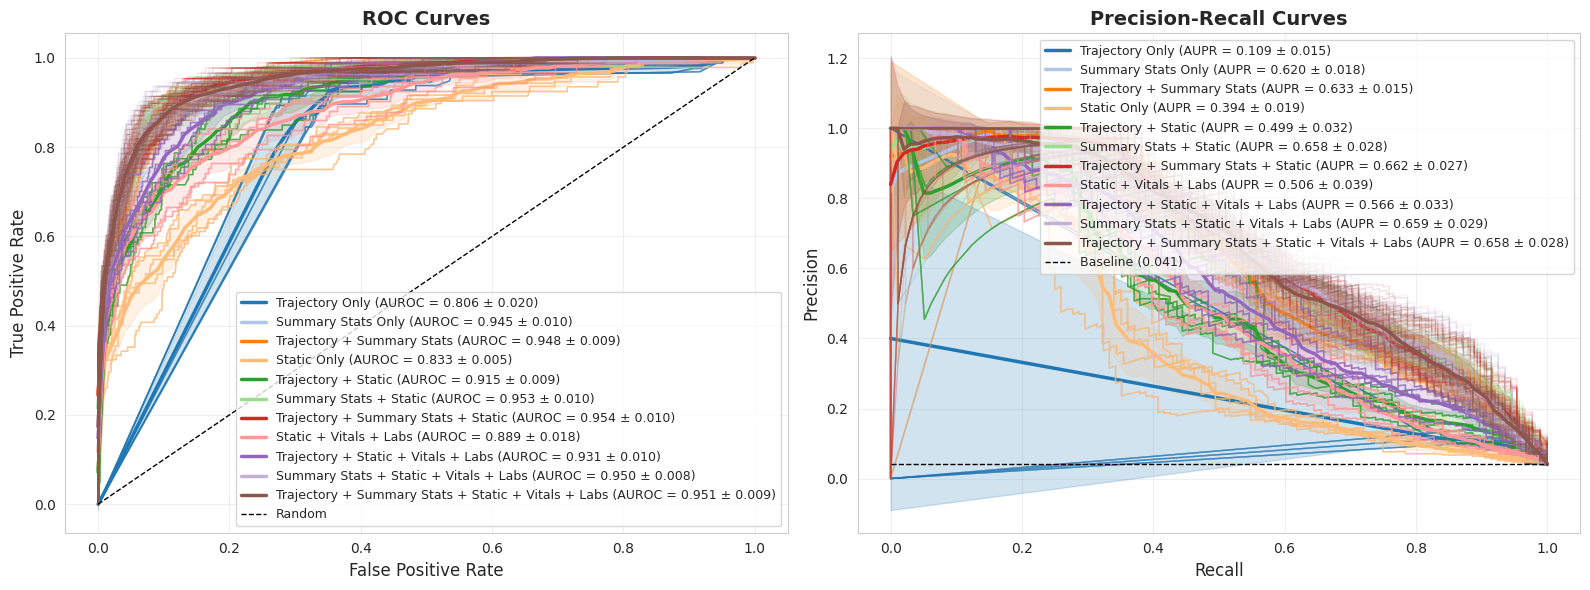

In [25]:
# Plot ROC curves for all feature sets with SD shading and fold curves
baseline = outcome_df['target_aclf'].mean()
plot_roc_pr_curves(
    comparison_results,
    prediction_clean,
    target_col='target_aclf',
    color_scheme='tab20'
)

In [26]:
print("\n✓ Liver failure (ACLF) analysis complete!")
print(f"\n  Clinical Impact:")
print(f"    - Early detection of acute decompensation (5-day window)")
print(f"    - Bilirubin trajectory patterns predict hepatic failure")
print(f"    - Enables timely transplant evaluation and supportive care")


✓ Liver failure (ACLF) analysis complete!

  Clinical Impact:
    - Early detection of acute decompensation (5-day window)
    - Bilirubin trajectory patterns predict hepatic failure
    - Enables timely transplant evaluation and supportive care
